In [45]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as variance_inflation_factor
from statsmodels.stats.anova import anova_lm

In [47]:
from sklearn.model_selection import train_test_split
from scipy import stats

In [48]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

## Simple Linear Regression

In [50]:
# replace this with `boston = load_data("Boston")`, in-built ISLP fuction
boston = pd.read_csv("/home/karan/ml/Datasets/islp/Boston.csv") 
boston.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'lstat', 'medv'],
      dtype='object')

In [51]:
boston.head(10)

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


In [52]:
# Extracting Predictor and Response
p = boston["lstat"]
r = boston["medv"]

x_train, x_test, y_train, y_test = train_test_split(p, r, test_size=0.2, random_state=42)

### Implementing SLR from scratch

Text(0, 0.5, 'Median Values (1000$)')

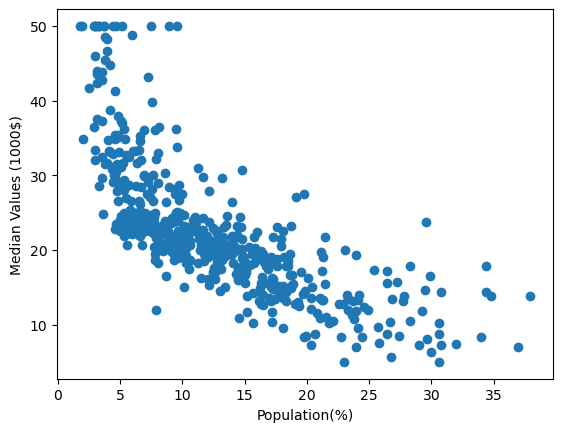

In [53]:
fig, ax = plt.subplots()
ax.scatter(x="lstat", y="medv", data=boston)
plt.xlabel("Population(%)")
plt.ylabel("Median Values (1000$)")


SLR model, $y_i = b_0 + b_1*x_i + e$ , e ~ $N(0, s^2)$

General Matrix Representation, $y = Xb$ , where $b^T = [b0, b1]$

using Least quare estimate for parameters,

$$
\hat{b}_1 = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{\sum_{i=1}^{n}(X_i - \bar{X})^2}
$$

$$
\hat{b}_0 = \bar{Y} - \hat{b}_1 \bar{X}
$$


In [54]:
# extracting raw values for calculations
x = x_train.values.tolist()
y = y_train.values.tolist()

y_bar = np.mean(y)
x_bar = np.mean(x)

# Numerator
S_xy = sum([(x[i] - x_bar)*(y[i] - y_bar) for i in range(len(y))])

# Denominator
S_xx = sum([(x_i - x_bar)**2 for x_i in x])


In [55]:
b1 = S_xy/S_xx
b0 = y_bar - b1*x_bar

In [56]:
print(f"b0 = {b0}\nb1 = {b1}")

b0 = 34.83694982031851
b1 = -0.966530901950353


Estimation model ,
$$
\hat{y}_i = 34.83695 - 0.96653*\hat{x}_i
$$

### Ploting the model

In [57]:
def model(x):
    return b0 + b1*x

In [58]:
# Estimates of model
y_hat = [model(i) for i in x]

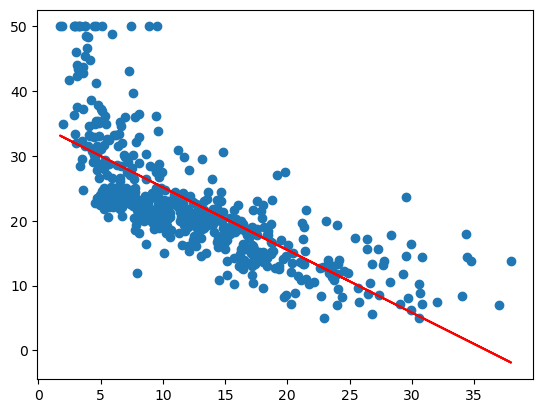

In [59]:
plt.scatter(x="lstat", y="medv", data=boston)
plt.plot(x, y_hat, color="red")
plt.show()

### Confidence Interval

provies an interal with $(1-\alpha)*100\% $ probability of containing the true value of model estimate for some $X_0 = x$

$$
\hat{Y}_0 \pm t_{n-2,\,1-\alpha/2} \times SE(\hat{Y}_0)
$$

$\alpha$ is called the significance level of confidence interval 


$$
SE(\hat{Y}_0) = \hat{\sigma} \sqrt{ \frac{1}{n} + \frac{(X_0 - \bar{X})^2}{\sum_{i=1}^{n} (X_i - \bar{X})^2} }
$$
$SE(\hat{Y}_0)$ is the standard error of estimate ,


$$
\hat{\sigma}^2 = \frac{1}{n - 2} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2
$$

where , $Var(\epsilon_{i}) = \sigma^2$, but since we dont know the actual value, we can estimate this from the data, hence $Var(\epsilon_{i}) = \hat{\sigma}^2$

In [ ]:
# RSS
n = len(y)
rss_train = sum([(y[i]-y_hat[i])**2 for i in range(n)])

# Residual Standard Error
rse = math.sqrt(rss_train/(n-2))

# Standard Error of Estimate

def se_y(x0):
    return rse*math.sqrt((1/n)+(((x0 - x_bar)**2)/S_xx))

def CI(x0, se, df, a=0.05):
    y0 = model(x0)
    t_crit = stats.t.ppf(1-a/2, df=df)  # by default a 95% CI
    unit = se*t_crit
    return (y0-unit, y0+unit)


In [61]:
# Calualting Confidence Interval for a random observation from given sample

# random predictor from training data
x0 = x[np.random.randint(0, n)]
l, u = CI(x0, se_y(x0), n-2)

# I know the Optimization is kinda Shit rn , I am making redundant function call 🥹
print(f"Confidence Interval at X_0  = {x0} and Y_0 = {model(x0)} is ({l}, {u})")

Confidence Interval at X_0  = 14.37 and Y_0 = 20.94790075929194 is (20.30761174208272, 21.58818977650116)


### Pridication Interval 
This interval is wider, since it includes both model uncertainty and random noise of new data. PI is used to pridict randomness in the estimates of model for new unseen data
$$
SE_{\text{pred}}(\hat{Y}_0) = \hat{\sigma} \sqrt{ 1 + \frac{1}{n} + \frac{(X_0 - \bar{X})^2}{\sum_{i=1}^{n} (X_i - \bar{X})^2} }
$$
$$
\hat{Y}_0 \pm t_{n-2,\,1-\alpha/2} \times SE_{\text{pred}}(\hat{Y}_0)

$$

In [ ]:
# Standard error for Prediction 

def se_y_pred(x0):
    return rse*math.sqrt(1 + (1/n)+(((x0 - x_bar)**2)/S_xx))

pl, pu = CI(x0, se_y_pred(x0), n-2)

print(f"Prediction Interval at X_0  = {x0} and Y_0 = {model(x0)} is ({pl}, {pu})")

# Clearly the pridiction interval is much more wider than the Confidence interval for the same value of x0

Prediction Interval at X_0  = 14.37 and Y_0 = 20.94790075929194 is (8.504580856296588, 33.391220662287296)


### Model Evaluation

##### 1. Residual Standard Error (RSE)

The RSE is an estimate of the standard
deviation of $\epsilon$. The average amount that the response
will deviate from the fitted regression line. It is computed using the formula

$$
RSE_{train} = \sqrt{\frac{RSS}{n - 2}}
$$

$$
RSS_{train} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

degree of freedom = (n-2)


In [63]:
# RSE
print(f"RSE = {rse}")

RSE = 6.321249852637818


##### 2. Root Mean Square Error

$$
RMSE_{test} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$



In [64]:
m = len(y_test)
y_tv = y_test.values.tolist()
x_tv = x_test.values.tolist()

In [65]:
# RSS on test data
y_test_hat = [model(i) for i in x_tv]
rss_test = sum([(y_tv[i]-y_test_hat[i])**2 for i in range(m)])

rmse = math.sqrt(rss_test/m)
print(f"RMSE on test data = {rmse}")

RMSE on test data = 5.789606996393182


##### 2. $R^2$ statistics

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

$$
R^2_{\text{test}} = 1 - \frac{\sum_{i=1}^{n_{\text{test}}} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n_{\text{test}}} (y_i - \bar{y}_{\text{test}})^2}
$$


where TSS is total sum of squares , basically total variation

In [66]:
#TSS of test data
y_test_bar = np.mean(y_tv)
tss_test = sum([(y_tv[i] - y_test_bar)**2 for i in range(m)])

r2_test = 1 - (rss_test/tss_test)

print(f"R Squarred (R^2) Statistics on test data = {r2_test}")

R Squarred (R^2) Statistics on test data = 0.5429180422970383


In [67]:
# TSS on train data

tss_train = sum([(y[i] - y_bar)**2 for i in range(n)])

r2_train = 1 - (rss_train/tss_train)

print(f"R Squarred (R^2) Statistics on train data = {r2_train}")

R Squarred (R^2) Statistics on train data = 0.542318073479352


The $R^2$ Statistics on test and train data are quite balanced , $R^2_{test} \approx R^2_{train}$, both values are around `0.54`, Hence **NO overfitting** is observed . 

I guess its just that one predictor is not enough to define the house prices (**Multiple Linear Regression !!!**) 